## School Type Classification Using PISA School Questionnaire Data (PCA + Clustering)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'IPAexGothic'
import os

pd.set_option('future.no_silent_downcasting', True)

### Data Loading (.sav)

In [2]:
import pyreadstat
import json

ROOT_DIR = os.getcwd()
# Load the SPSS file (data + metadata)
df, meta = pyreadstat.read_sav(os.path.join(ROOT_DIR, "CY07_MSU_SCH_QQQ.sav"))
# Create a dictionary mapping column names to their labels
col_to_label = dict(zip(meta.column_names, meta.column_labels))

# Save metadata as a JSON file (optional)
#with open("CY07_MSU_SCH_QQQ_metadata.json", "w", encoding="utf-8") as f:
#    json.dump(col_to_label, f, ensure_ascii=False, indent=2)

# Save the extracted Japanese school data as CSV for faster processing (optional)
#df_school = df[df["CNT"] == "JPN"].copy()
#df_school.to_csv(os.path.join(ROOT_DIR, "CY07_MSU_SCH_QQQ_JPN.csv"), index=False)

# Load the CSV file for subsequent analysis
df_school = pd.read_csv(os.path.join(ROOT_DIR, "CY07_MSU_SCH_QQQ_JPN.csv"))
df_school.shape

(183, 197)

In [3]:
pd.set_option('display.max_info_columns', 10000)
df_school.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183 entries, 0 to 182
Data columns (total 197 columns):
 #    Column            Non-Null Count  Dtype  
---   ------            --------------  -----  
 0    CNTRYID           183 non-null    object 
 1    CNT               183 non-null    object 
 2    CNTSCHID          183 non-null    float64
 3    CYC               183 non-null    object 
 4    NatCen            183 non-null    object 
 5    Region            183 non-null    object 
 6    STRATUM           183 non-null    object 
 7    SUBNATIO          183 non-null    object 
 8    OECD              183 non-null    object 
 9    ADMINMODE         183 non-null    object 
 10   LANGTEST          183 non-null    object 
 11   SC001Q01TA        183 non-null    object 
 12   SC013Q01TA        183 non-null    object 
 13   SC016Q01TA        183 non-null    float64
 14   SC016Q02TA        183 non-null    float64
 15   SC016Q03TA        183 non-null    float64
 16   SC016Q04TA        183 no

### Preprocessing

In [4]:
import re
from sklearn.preprocessing import LabelEncoder

# Identify columns containing missing values
cols_with_nan = df_school.columns[df_school.isna().any() | (df_school.eq('').any())]
# Identify columns without missing values
cols_without_nan = [cols for cols in df_school.columns if cols not in cols_with_nan]

df_school = df_school[cols_without_nan]

# Separate numerical and categorical data
df_float = df_school.copy().select_dtypes(include=['float'])
df_object = df_school.copy().select_dtypes(include=['object'])

# Select categorical columns
# Count the number of unique values per column
unique_counts = df_object.nunique()
# Extract columns that are not binary (Yes/No) → typically 3-, 4-, or 9-point Likert scales
likert_cols = unique_counts[unique_counts.isin([3, 4, 9])].index.tolist()
df_likert = df_object[likert_cols].copy()

# Split selected categorical columns into ordinal (Likert) and nominal scales
likert_map = {
    "Strongly disagree": 1,
    "Disagree": 2,
    "Agree": 3,
    "Strongly agree": 4,
    "Not at all": 1,
    "Very little": 2,
    "To some extent": 3,
    "A lot": 4,
    "Never": 1,
    "Sometimes": 2,
    "Always": 3,
    "More than 50 students": 9,
    "46-50 students": 8,
    "41-45 students": 7,
    "36-40 students": 6,
    "31-35 students": 5,
    "26-30 students": 4,
    "21-25 students": 3,
    "16-20 students": 2,
    "15 students or fewer": 1,
}

df_temp = df_likert.copy()

lik_cols = []
nom_cols = []

# Common text patterns found in Likert-scale responses
likert_patterns = [
    r"strongly agree", r"agree", r"disagree", r"strongly disagree",
    r"never", r"sometimes", r"always",
    r"not at all", r"very little", r"to some extent", r"a lot",
    r"15 students or fewer"
]

def is_likert_string(series):
    sample = series.dropna().astype(str).str.lower()
    for p in likert_patterns:
        if sample.str.contains(p).any():
            return True
    return False

for col in df_temp.columns:
    series = df_temp[col]
    # Detect Likert-scale items based on text patterns
    if is_likert_string(series):
        lik_cols.append(col)
        continue
    # Otherwise → treat as nominal scale
    nom_cols.append(col)

print("Total cols", len(df_temp.columns))
print("Likert cols:", len(lik_cols))
print("Nominal cols:", len(nom_cols))

# Encode ordinal and nominal variables separately
df_encoded_likert = df_likert[lik_cols].copy()
df_encoded_nominal = df_likert[nom_cols].copy()
# Encode ordinal (Likert) variables
for col in lik_cols:
    df_encoded_likert.loc[:, col] = df_encoded_likert[col].replace(likert_map)
# Encode nominal variables
for col in nom_cols:
    le = LabelEncoder()
    df_encoded_nominal[col] = le.fit_transform(df_encoded_nominal[col].astype(str))
# Combine encoded ordinal and nominal variables
df_encoded = pd.concat([df_encoded_likert, df_encoded_nominal], axis=1)

# Combine numerical and categorical variables into the final dataset
df_all = pd.concat([df_float, df_encoded], axis=1)
df_all.shape


Total cols 53
Likert cols: 38
Nominal cols: 15


(183, 87)

### Dimensionality Reduction and Clustering Using PCA

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Standardize the dataset
X = StandardScaler().fit_transform(df_all)

# Perform PCA (reduce to 8 dimensions)
pca_all = PCA(n_components=8, random_state=42)
X_pca_all = pca_all.fit_transform(X)

# Apply KMeans clustering (example: 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca_all)

#### Cumulative Explained Variance

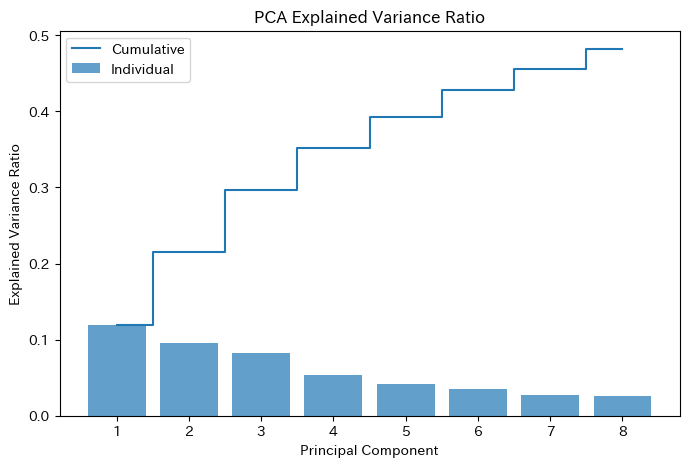

In [6]:
# Explained variance ratio
explained = pca_all.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained)+1), explained, alpha=0.7, label="Individual")
plt.step(range(1, len(explained)+1), np.cumsum(explained), where='mid', label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance Ratio")
plt.legend()
plt.show()


#### Elbow Method

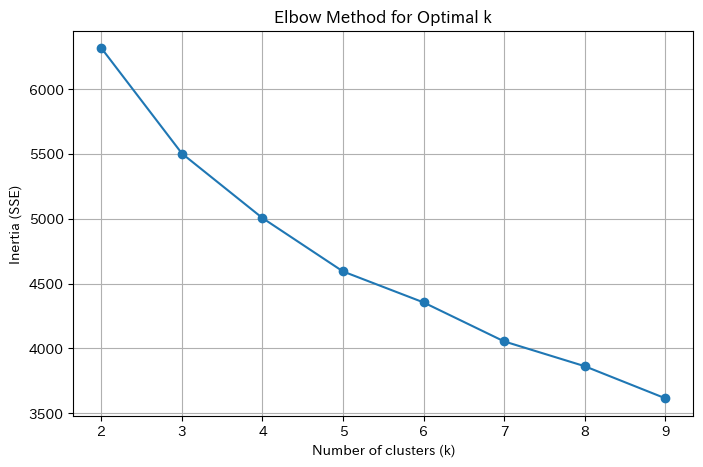

In [7]:
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_all)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for Optimal k")
plt.grid(True)
plt.show()


#### Silhouette Analysis

In [8]:
from sklearn.metrics import silhouette_score

# KMeans with 3 clusters
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(X_pca_all)
sil_3 = silhouette_score(X_pca_all, labels_3)

# KMeans with 4 clusters
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(X_pca_all)
sil_4 = silhouette_score(X_pca_all, labels_4)

print("Silhouette Score (3 clusters):", sil_3)
print("Silhouette Score (4 clusters):", sil_4)


Silhouette Score (3 clusters): 0.14582638955624264
Silhouette Score (4 clusters): 0.1453512773467377


#### Biplot Visualization

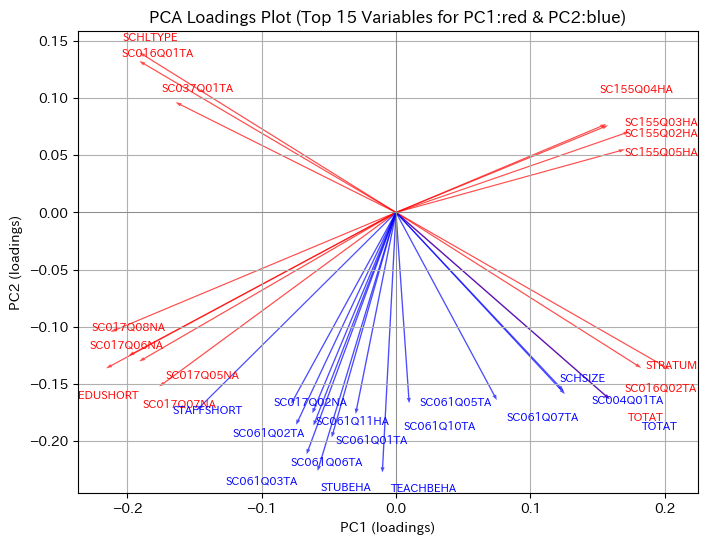

In [9]:
from adjustText import adjust_text

# Create a DataFrame of PCA loadings (factor loadings)
loadings = pd.DataFrame(
    pca_all.components_.T,
    columns=[f"PC{i+1}" for i in range(pca_all.n_components_)],
    index=df_all.columns
)

# Compute absolute values for PC1 and PC2 loadings
loadings["abs_PC1"] = loadings["PC1"].abs()
loadings["abs_PC2"] = loadings["PC2"].abs()

# Extract the top 15 variables with the largest absolute loadings for PC1 and PC2
top_PC1 = loadings.sort_values("abs_PC1", ascending=False).head(15)
top_PC2 = loadings.sort_values("abs_PC2", ascending=False).head(15)

# Visualization
plt.figure(figsize=(8, 6))

texts_PC1 = []
texts_PC2 = []

# Plot top 15 PC1 variables (red)
for var in top_PC1.index:
    x = loadings.loc[var, "PC1"]
    y = loadings.loc[var, "PC2"]
    plt.arrow(0, 0, x, y, color='red', alpha=0.7, linewidth=0.001)
    txt = plt.text(x * 1.1, y * 1.1, var, color='red', fontsize=8)
    texts_PC1.append(txt)

# Plot top 15 PC2 variables (blue)
for var in top_PC2.index:
    x = loadings.loc[var, "PC1"]
    y = loadings.loc[var, "PC2"]
    plt.arrow(0, 0, x, y, color='blue', alpha=0.7, linewidth=0.001)
    txt = plt.text(x * 1.1, y * 1.1, var, color='blue', fontsize=8)
    texts_PC2.append(txt)

# Adjust overlapping labels (PC1 and PC2 handled separately)
adjust_text(
    texts_PC1,
    only_move={'points':'xy', 'text':'xy'},
    #arrowprops=dict(arrowstyle='-', color='red', lw=0.5),
    force_text=5
)

adjust_text(
    texts_PC2,
    only_move={'points':'xy', 'text':'xy'},
    #arrowprops=dict(arrowstyle='-', color='blue', lw=0.5),
    force_text=5
)

plt.xlabel("PC1 (loadings)")
plt.ylabel("PC2 (loadings)")
plt.title("PCA Loadings Plot (Top 15 Variables for PC1:red & PC2:blue)")
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True)
plt.show()


#### Clustering Based on PC1 and PC2

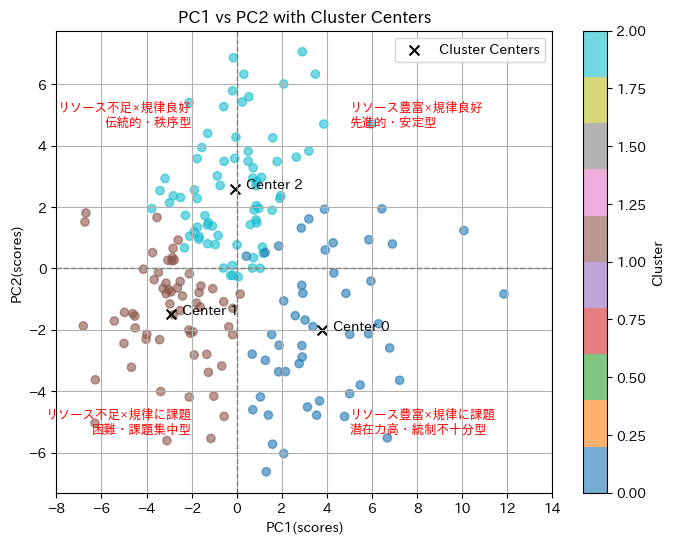

In [10]:
# Cluster centers (centroids in the PC1–PC2 space)
cluster_centers = np.array([
    X_pca_all[clusters == k, :2].mean(axis=0)  # PC1, PC2 の平均
    for k in range(3)
])

plt.figure(figsize=(8, 6))

# Scatter plot of schools
scatter = plt.scatter(
    X_pca_all[:, 0], X_pca_all[:, 1],
    c=clusters, cmap="tab10", alpha=0.6
)

# Plot cluster centers
plt.scatter(
    cluster_centers[:, 0], cluster_centers[:, 1],
    c="black", s=50, marker="x", label="Cluster Centers"
)

# Add labels to cluster centers
for i, (x, y) in enumerate(cluster_centers):
    plt.text(x+0.5, y, f"Center {i}", fontsize=10, color="black")

# Draw quadrant boundaries (PC1 = 0, PC2 = 0)
plt.axvline(x=0, color="gray", linestyle="--", linewidth=1.0)
plt.axhline(y=0, color="gray", linestyle="--", linewidth=1.0)

# Add school-type labels directly on the plot
plt.text( 5.0,  5.0, "リソース豊富×規律良好\n先進的・安定型", fontsize=9, color="red", ha="left", va="center")
plt.text(-2.0,  5.0, "リソース不足×規律良好\n伝統的・秩序型", fontsize=9, color="red", ha="right", va="center")
plt.text(-2.0, -5.0, "リソース不足×規律に課題\n困難・課題集中型", fontsize=9, color="red", ha="right", va="center")
plt.text(5.0, -5.0, "リソース豊富×規律に課題\n潜在力高・統制不十分型", fontsize=9, color="red", ha="left", va="center")

# Adjust PC1 tick marks to even intervals
xmin, xmax = plt.xlim()
xmin_even = np.floor(xmin / 2) * 2
xmax_even = np.ceil(xmax / 2) * 2
plt.xticks(np.arange(xmin_even, xmax_even + 1, 2))

plt.xlabel("PC1(scores)")
plt.ylabel("PC2(scores)")
plt.title("PC1 vs PC2 with Cluster Centers")
plt.legend()
plt.grid(True)
plt.colorbar(scatter, label="Cluster")
plt.show()


### Bar Plot of Factor Loadings
#### Top 20 Variables for PC1 (Bar Plot)

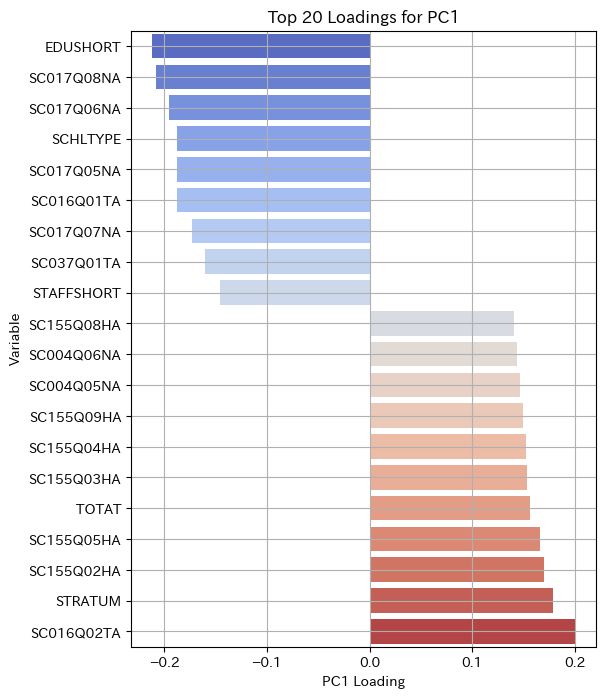

In [11]:
# Top 20 variables with the largest absolute loadings on PC1
top20_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(20).index
df_pc1 = loadings.loc[top20_pc1].sort_values("PC1")

plt.figure(figsize=(6, 8))
sns.barplot(
    x="PC1",
    y=df_pc1.index,
    data=df_pc1,
    hue=df_pc1.index,
    palette="coolwarm",
    legend=False
)
plt.title("Top 20 Loadings for PC1")
plt.xlabel("PC1 Loading")
plt.ylabel("Variable")
plt.grid(True)
plt.show()

#### Top 20 Variables for PC2 (Bar Plot)

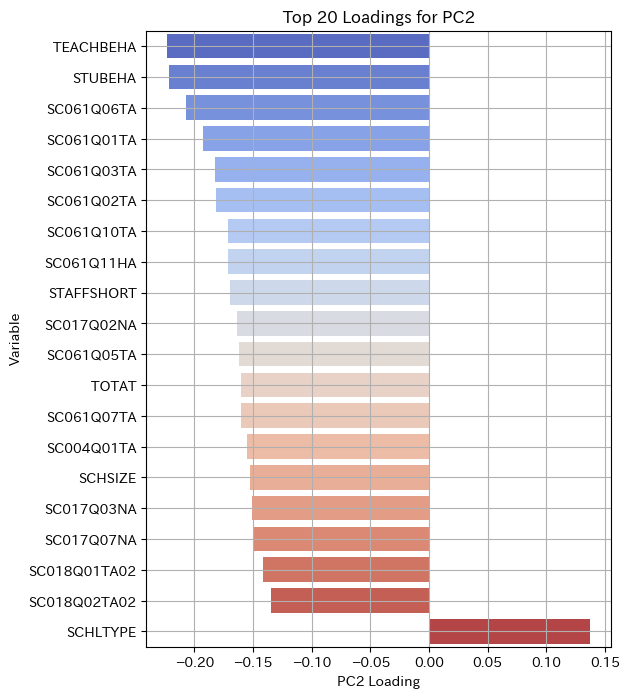

In [12]:
# Top 20 variables with the largest absolute loadings on PC2
top20_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(20).index
df_pc2 = loadings.loc[top20_pc2].sort_values("PC2")

plt.figure(figsize=(6, 8))
sns.barplot(
    x="PC2",
    y=df_pc2.index,
    data=df_pc2,
    hue=df_pc2.index,
    palette="coolwarm",
    legend=False
)
plt.title("Top 20 Loadings for PC2")
plt.xlabel("PC2 Loading")
plt.ylabel("Variable")
plt.grid(True)
plt.show()

### Heatmap of Variables × PC1–PC5

<Figure size 1200x1400 with 0 Axes>

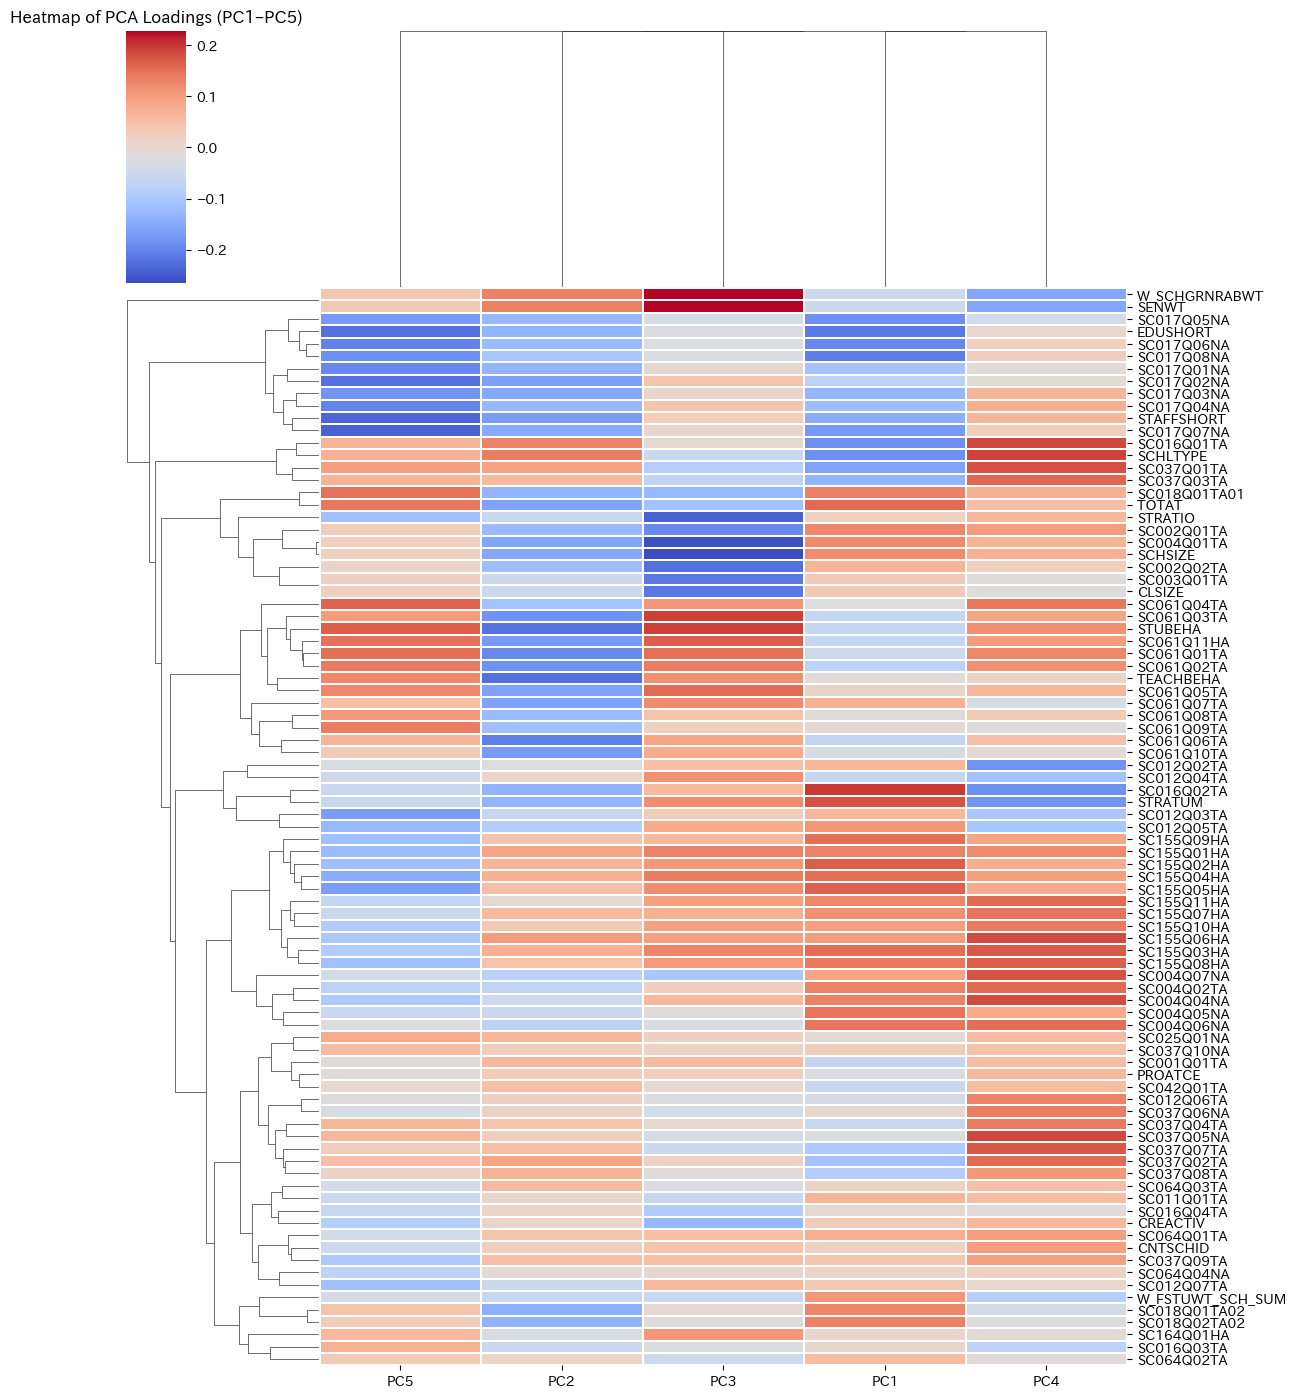

In [13]:
plt.figure(figsize=(12, 14))
sns.clustermap(
    loadings.iloc[:, :5],  # PC1〜PC5
    cmap="coolwarm",
    linewidths=0.1,
    figsize=(12, 14),
    yticklabels=True,
    xticklabels=["PC1", "PC2", "PC3", "PC4", "PC5"]
)
plt.title("Heatmap of PCA Loadings (PC1–PC5)")
plt.show()

### Cluster-wise Mean Values
#### Cluster Consistency Check

In [14]:
df_school_val = df_all.copy()
df_school_val["cluster"] = clusters

cluster_means_all = df_school_val.groupby("cluster").mean()
cluster_means_all

,CNTSCHID,SC016Q01TA,SC016Q02TA,SC016Q03TA,SC016Q04TA,SC002Q01TA,SC002Q02TA,SC004Q01TA,SC004Q02TA,SC004Q04NA,...,SC037Q02TA,SC037Q03TA,SC037Q04TA,SC037Q05NA,SC037Q06NA,SC037Q07TA,SC037Q08TA,SC037Q09TA,SC037Q10NA,SCHLTYPE
cluster,,,,,,,,,,,,,,,,,,,,,
0,3.920009e+07,34.040816,51.816327,1.612245,12.530612,490.530612,494.836735,326.816327,134.081633,54.632653,...,0.530612,0.979592,0.591837,1.183673,1.204082,0.755102,0.816327,0.183673,0.408163,0.918367
1,3.920009e+07,79.540984,5.557377,1.836066,13.065574,313.278689,341.409836,221.409836,90.459016,19.983607,...,1.491803,1.590164,1.000000,1.344262,1.196721,1.245902,1.229508,0.098361,0.229508,1.901639
2,3.920009e+07,84.273973,2.150685,0.630137,12.945205,323.479452,317.273973,211.452055,98.849315,25.342466,...,1.424658,1.616438,0.986301,1.547945,1.287671,1.246575,1.150685,0.273973,0.493151,1.945205


#### Cluster-wise Mean Values for Top 20 PC1/PC2 Variables

In [15]:
pc1_cols = list(df_pc1.index)
pc2_cols = list(df_pc2.index)
print("=====PC1=====")
for col in pc1_cols:
    print(cluster_means_all[col])
    print()

print("=====PC2=====")
for col in pc2_cols:
    print(cluster_means_all[col])
    print()

=====PC1=====
cluster
0    0.308229
1    1.488207
2    0.411026
Name: EDUSHORT, dtype: float64

cluster
0    2.081633
1    3.196721
2    2.383562
Name: SC017Q08NA, dtype: object

cluster
0    2.081633
1    2.983607
2    2.164384
Name: SC017Q06NA, dtype: object

cluster
0    0.918367
1    1.901639
2    1.945205
Name: SCHLTYPE, dtype: float64

cluster
0    2.326531
1    3.131148
2    2.328767
Name: SC017Q05NA, dtype: object

cluster
0    34.040816
1    79.540984
2    84.273973
Name: SC016Q01TA, dtype: float64

cluster
0    2.387755
1    3.295082
2     2.30137
Name: SC017Q07NA, dtype: object

cluster
0    1.102041
1    1.803279
2    1.808219
Name: SC037Q01TA, dtype: float64

cluster
0    0.765006
1    1.506261
2    0.587670
Name: STAFFSHORT, dtype: float64

cluster
0    2.163265
1    1.754098
2    2.013699
Name: SC155Q08HA, dtype: object

cluster
0    23.448980
1    11.262295
2    12.493151
Name: SC004Q06NA, dtype: float64

cluster
0    11.755102
1     1.360656
2     3.821918
Name: SC004Q